# Convolutional Autoencoders

![autoencoder](notebook_images/autoencoder.jpg)



A **Convolutional Autoencoder (AE)** is a neural network architecture designed to learn efficient representations of image data by compressing and reconstructing images. It consists of two main parts:

- **Encoder:** This component processes the input image through a series of convolutional layers, gradually reducing its spatial dimensions and complexity. The encoder outputs a compact, lower-dimensional representation called the **latent space**. The latent space acts as a bottleneck that captures the most essential features of the image in a compressed form.

- **Decoder:** The decoder takes this **latent space** representation and reconstructs an image by progressively upsampling and/or applying transposed convolutional layers. 

While the output is often intended to be a reconstruction of the input, it does not have to be identical. In tasks like denoising or colorization, the output image may differ intentionally.

## Unsupervised Learning

Convolutional autoencoders are typically trained using **unsupervised learning**:

- Training data consists solely of images, without labels or annotations.
- The network learns by minimizing the difference (e.g., mean squared error) between the input images and their reconstructions.
- Through this process, the autoencoder discovers meaningful patterns and compresses the data into the latent space.

## Applications

Common applications of convolutional autoencoders include:

- **Dimensionality Reduction:** Compressing images into compact feature vectors;
- **Image Denoising:** Removing noise from images;
- **Anomaly Detection:** Spotting unusual images via reconstruction error;


## References for Additional Material:

- *Auto-Encoders in Deep Learning—A Review with New Perspectives*, Shuangshuang Chen and Wei Guo - https://www.mdpi.com/2227-7390/11/8/1777

- *Autoencoders in Deep Learning: Tutorial & Use Cases*, Hmrishav Bandyopadhyay - https://www.v7labs.com/blog/autoencoders-guide

- *Introduction to Autoencoders*, Aditya Sharma - https://pyimagesearch.com/2023/07/10/introduction-to-autoencoders/

- *Introduction to Autoencoders: From The Basics to Advanced Applications in PyTorch*, Pier Paolo Ippolito - https://www.datacamp.com/tutorial/introduction-to-autoencoders

- *Auto-Encoder: What Is It? And What Is It Used For?*, Will Badr -https://towardsdatascience.com/applied-deep-learning-part-3-autoencoders-1c083af4d798




In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time
import glob


import os
import pathlib
from PIL import Image
import skimage
from tqdm import tqdm

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

print(torch.__version__)

2.2.1+cu118


## Auxiliary functions for training, evaluation and result visualization

The focus here is on the architecture and applications of autoencoders (AEs), rather that the training process itself. As the training procedure is similar to that of CNNs, these functions are imported from earlier notebooks in this course

In [2]:
def train(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix='model', device='cuda'):
    history = {'loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        start_time = time.time()
        running_loss = 0.0
        total_train_samples = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            # Dynamically handle standard vs. denoising datasets
            if len(batch) == 2:
                inputs, _ = batch
                targets = inputs  # Standard AE: reconstruct the input
            elif len(batch) == 3:
                inputs, targets, _ = batch  # Denoising AE: reconstruct clean from noisy
            else:
                raise ValueError("Expected batch to have 2 or 3 elements.")
                
            inputs = inputs.to(device)
            targets = targets.to(device)
            batch_size = inputs.size(0)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            
            # FIX: Correct loss accumulation
            running_loss += loss.item() * batch_size
            total_train_samples += batch_size
            
        epoch_loss = running_loss / total_train_samples
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        total_val_samples = 0
        
        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 2:
                    inputs, _ = batch
                    targets = inputs
                else:
                    inputs, targets, _ = batch
                    
                inputs = inputs.to(device)
                targets = targets.to(device)
                batch_size = inputs.size(0)
                
                outputs = model(inputs)
                batch_loss = loss_fn(outputs, targets)
                
                val_loss += batch_loss.item() * batch_size
                total_val_samples += batch_size
                
        epoch_val_loss = val_loss / total_val_samples
        
        # --- Scheduling and Logging ---
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(epoch_val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print(f'==> Learning rate updated: {old_lr:.6f} -> {new_lr:.6f}')
            
        stop_time = time.time()
        print(f'Epoch: {epoch:03d} | Loss: {epoch_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | Time: {(stop_time - start_time):.4f}s')
        
        history['loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        
        # --- Saving Best Model ---
        if epoch_val_loss < best_val_loss:
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'history': history,
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
            }, f'{save_prefix}_best.pt')
            best_val_loss = epoch_val_loss
            
        # --- Early Stopping ---
        if early_stopper(epoch_val_loss):
            print('Early stopping triggered!')
            break
            
    print('Finished Training')
    return history

    
class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    
from matplotlib import colors

def plot_scatter(x,y,targets, lims = None):
    cmap = colors.ListedColormap(['black', 'darkred', 'darkblue', 
                                  'darkgreen', 'yellow', 'brown', 
                                  'purple', 'lightgreen', 'red', 'lightblue'])
    bounds=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,8.5,9.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    if lims != None:
        s = 50
    else: s = 1

    plt.figure(figsize=(10,10))
    plt.scatter(x, y, c = targets, cmap=cmap, s = s, norm=norm)
    plt.colorbar()
    if lims != None:
         plt.xlim(lims[0], lims[2])
         plt.ylim(lims[1], lims[3])

    plt.show()


def show_preds(set1, set2, count):
  
  columns = 4
  rows = int(count*2 / columns) + 1  
  plt.figure(figsize=(count, 2 * rows))
  
  for n in range(count):
      ax = plt.subplot(rows, columns, n*2+1)
      plt.title("original")
      plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray)
      plt.axis('off')
      ax = plt.subplot(rows, columns, n*2+2)
      plt.title("reconstruction")
      plt.imshow(np.transpose(set2[n].cpu().detach().numpy(), (1,2,0)), 
                 cmap=plt.cm.gray)
      plt.axis('off')        


def show_images(rows, cols, images, targets):

    width= 2 * rows
    height= 2 * cols

    f, axes= plt.subplots(rows,cols,figsize=(height,width))
    fig=plt.figure()

    for a in range(rows*cols):
        img, target = images[a], targets[a]
        axes.ravel()[a].imshow(np.transpose(img.numpy(),(1,2,0)), 
                               cmap=plt.cm.gray)
        axes.ravel()[a].axis('off')
    fig.tight_layout()    
    plt.show()          


def show_content_retrieval(train_X, top50):

    fig = plt.figure(figsize=(10,50))
    for i in range(len(top50)):
        ax = plt.subplot(25,5,i+1)
        plt.imshow(np.transpose(train_X[top50[i][1]][0], (1,2,0)), 
                   cmap='gray')
        plt.title(f'{top50[i][0]:.3f}')
        plt.axis('off')   



def show_anomaly_sample(image, recon, err):
        plt.figure(figsize=(5,2))
        ax = plt.subplot(1,2,1)
        plt.imshow(image, cmap='gray')
        plt.title(str(err))
        ax = plt.subplot(1,2,2)
        plt.imshow(recon, cmap='gray')
        plt.axis('off')


def load_model(latent_space_dim, path = None):
    if path == None:
        reload = torch.load(f'{MODEL_PATH}/autoencoder_{latent_space_dim}_best.pt')
    else:
        reload = torch.load(path)
    AE = AutoEncoder(latent_space_dim, input_shape=(1, 28, 28))
    AE.to(device)
    AE.load_state_dict(reload['model'])
    return AE


def show_anomaly_evaluation(images, reconstructions, errors, threshold):
    count = len(images)
    plt.figure(figsize=(count * 2, 4))
    
    for n in range(count):
        # Original Image
        ax = plt.subplot(2, count, n + 1)
        plt.title("OOD Input")
        plt.imshow(images[n].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # Reconstructed Image
        ax = plt.subplot(2, count, n + count + 1)
        
        # Color title red if it breaches the anomaly threshold
        color = 'red' if errors[n] > threshold else 'green'
        plt.title(f"MSE: {errors[n]:.4f}", color=color)
        
        plt.imshow(reconstructions[n].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()


def show_error_distribution(errors, threshold):

        # Define threshold as the 99th percentile of in-distribution errors

    # Plot the distribution of In-Distribution MSE errors
    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=100, color='royalblue', alpha=0.7, label='In-Distribution (MNIST) MSE')
    plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, 
                label=f'99th Percentile Threshold ({threshold:.4f})')

    plt.title('Distribution of Reconstruction Errors (MSE) on In-Distribution Data')
    plt.xlabel('Mean Squared Error (MSE)')
    plt.ylabel('Frequency (Number of Images)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    print(f"In-Distribution MSE - Mean: {np.mean(errors):.4f}, Std: {np.std(errors):.4f}")
    print(f"Anomaly Threshold (99th percentile): {threshold:.4f}")



def show_both_error_distribution(id_errors, ood_errors, threshold):
    # 2. Plot both distributions superimposed
    plt.figure(figsize=(12, 6))

    # Plot In-Distribution (MNIST)
    plt.hist(id_errors, bins=100, color='royalblue', alpha=0.7, density=True, 
            label='In-Distribution (MNIST)')

    # Plot Out-of-Distribution (FashionMNIST)
    plt.hist(ood_errors, bins=100, color='crimson', alpha=0.7, density=True, 
            label='Out-of-Distribution (FashionMNIST)')

    # Plot the Threshold
    plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, 
                label=f'99th Percentile Threshold ({threshold:.4f})')

    plt.title('Separability of In-Distribution vs. Out-of-Distribution Reconstruction Errors')
    plt.xlabel('Mean Squared Error (MSE)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    print(f"In-Distribution (MNIST) MSE        - Mean: {np.mean(id_errors):.4f}, Std: {np.std(id_errors):.4f}")
    print(f"Out-of-Distribution (Fashion) MSE  - Mean: {np.mean(ood_errors):.4f}, Std: {np.std(ood_errors):.4f}")    


def show_false_positives(images, reconstructions, errors, threshold, max_display=10):
    count = len(images)
    plt.figure(figsize=(count * 2, 4))

    for i in range(count):
        # Original Image
        ax = plt.subplot(2, count, i + 1)
        #plt.title("Poorly Written")
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
        
        # Reconstructed Image
        ax = plt.subplot(2, count, i + count + 1)
        plt.title(f"MSE: {errors[i]:.4f}", color='red')
        plt.imshow(reconstructions[i], cmap='gray')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()


def loss_plot(latent_dims):

    c = len(latent_dims)
    f, axes= plt.subplots(1,c, figsize=(c*3,3))
    fig=plt.figure()  

    for index, i in enumerate(latent_dims):
        reload = torch.load(f'{MODEL_PATH}/autoencoder_{i}_best.pt')
        history = reload['history']
        axes[index].plot(history['loss'])
        axes[index].set_ylim(0, 0.06)
        axes[index].set_xlim(0, 50)
        axes[index].set_title(f'{i}')
        axes[index].grid(axis = 'y')
        if index > 0:
            axes[index].set_yticklabels([])

        
    plt.show()        



def apply_extreme_noise(images, amount=0.3):
    """Applies severe Salt & Pepper noise to a batch of tensors."""
    noisy_images = images.clone().cpu().numpy()
    for i in range(noisy_images.shape[0]):
        noisy_images[i] = skimage.util.random_noise(noisy_images[i], mode='s&p', amount=amount)
    return torch.tensor(noisy_images, dtype=torch.float32).to(device)

def compare_extreme_noise(clean, noisy, recon_std, recon_dae, count=8):
    plt.figure(figsize=(count * 2, 8))
    
    for i in range(count):
        # 1. Clean Image
        ax = plt.subplot(4, count, i + 1)
        if i == 0: plt.ylabel("Clean", fontsize=12)
        plt.imshow(clean[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # 2. Extreme Noisy Input
        ax = plt.subplot(4, count, i + count + 1)
        if i == 0: plt.ylabel("Extreme Noise", fontsize=12)
        plt.imshow(noisy[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # 3. Standard AE Reconstruction
        ax = plt.subplot(4, count, i + 2*count + 1)
        if i == 0: plt.ylabel("Standard AE", fontsize=12)
        plt.imshow(recon_std[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # 4. DAE Reconstruction
        ax = plt.subplot(4, count, i + 3*count + 1)
        if i == 0: plt.ylabel("Denoising AE", fontsize=12)
        plt.imshow(recon_dae[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()  


def compare_reconstructions(images, recon_std, recon_dae, count=8):
    plt.figure(figsize=(count * 3, 9))
    
    for i in range(count):
        # 1. Original Clean Image
        ax = plt.subplot(3, count, i + 1)
        if i == 0: plt.ylabel("Original", fontsize=12)
        plt.imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # 2. Standard AE Reconstruction
        ax = plt.subplot(3, count, i + count + 1)
        if i == 0: plt.ylabel("Standard AE", fontsize=12)
        plt.imshow(recon_std[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # 3. DAE Reconstruction
        ax = plt.subplot(3, count, i + 2*count + 1)
        if i == 0: plt.ylabel("Denoising AE", fontsize=12)
        plt.imshow(recon_dae[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()      


def show_gaussian_comparison(clean_images, gaussian_noisy_images, recon_std_gauss, recon_dae_gauss, count=8) : 
    # 2. Visual Comparison
    count = 8
    plt.figure(figsize=(count * 2, 8))

    for i in range(count):
        # Clean Image
        ax = plt.subplot(4, count, i + 1)
        if i == 0: plt.ylabel("Clean", fontsize=12)
        plt.imshow(clean_images[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # Gaussian Noisy Input
        ax = plt.subplot(4, count, i + count + 1)
        if i == 0: plt.ylabel("Gaussian Noise", fontsize=12)
        plt.imshow(gaussian_noisy_images[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # Standard AE Reconstruction
        ax = plt.subplot(4, count, i + 2*count + 1)
        if i == 0: plt.ylabel("Standard AE", fontsize=12)
        plt.imshow(recon_std_gauss[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
        # Denoising AE Reconstruction
        ax = plt.subplot(4, count, i + 3*count + 1)
        if i == 0: plt.ylabel("Denoising AE", fontsize=12)
        plt.imshow(recon_dae_gauss[i].cpu().numpy().squeeze(), cmap='gray')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()    


def plot_interpolation(interp_std, interp_dae):
    # Plot the results
    plt.figure(figsize=(20, 4)) # Increased width to accommodate 20 columns

    for i in range(steps):
        # Standard AE Interpolation (Top Row: indices 1 to 20)
        ax = plt.subplot(2, steps, i + 1)
        if i == 0: plt.ylabel("Standard AE", fontsize=12)
        plt.imshow(interp_std[i].squeeze(), cmap='gray')
        plt.axis('off')
        
        # Denoising AE Interpolation (Bottom Row: indices 21 to 40)
        ax = plt.subplot(2, steps, i + steps + 1)
        if i == 0: plt.ylabel("Denoising AE", fontsize=12)
        plt.imshow(interp_dae[i].squeeze(), cmap='gray')
        plt.axis('off')

    plt.suptitle("Latent Space Interpolation: Standard vs. Denoising Autoencoder", fontsize=16)
    plt.tight_layout()
    plt.show()


# Configuration

In [3]:
HEIGHT = 28
WIDTH = 28
NUM_CHANNELS = 1
BATCH_SIZE = 32
LATENT_SPACE_DIM = 2

MODEL_PATH = 'autoencoder_models'

# defines if training, or using already pre-trained models. 
# Set to TRUE in the first run 
# of this notebook, and FALSE for subsequent runs
TRAIN = False

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# Load and prepare MNIST dataset

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor()]) 

full_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_set, val_set = torch.utils.data.random_split(full_dataset, 
                                                   [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, 
                                           shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)

test_set = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                         shuffle=False)

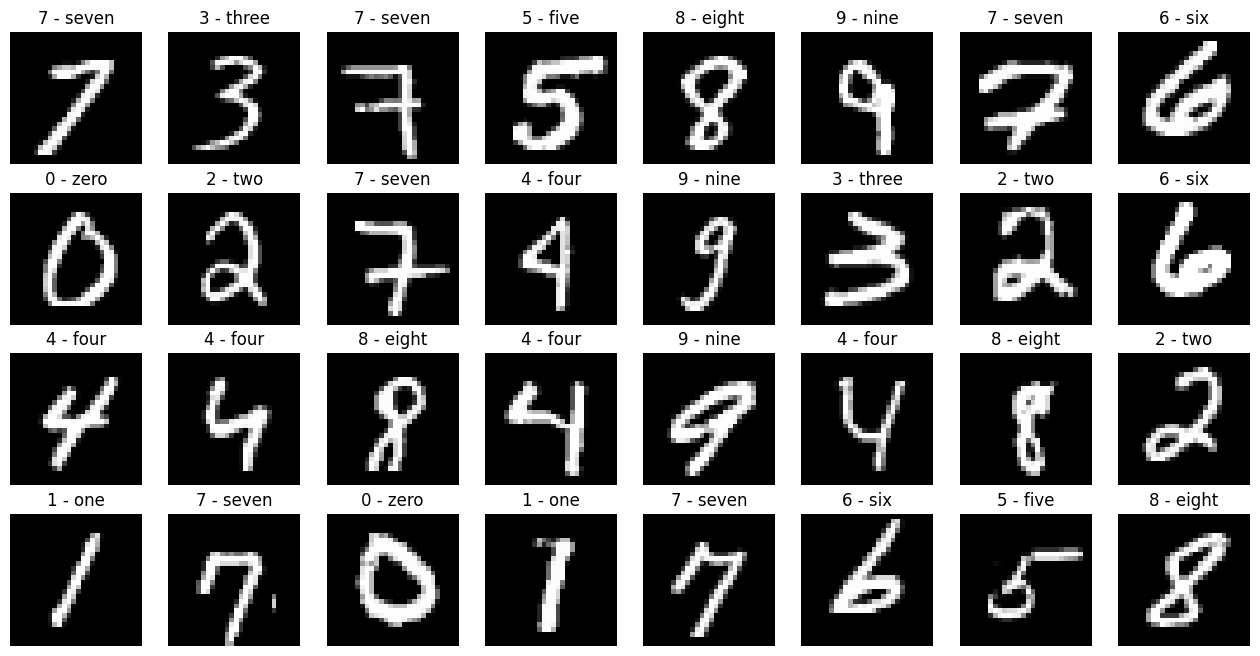

<Figure size 640x480 with 0 Axes>

In [5]:
images, targets = next(iter(train_loader))

vcpi_util.show_images(4,8, images, targets, full_dataset.classes) 

# Autoencoder for reconstruction

![reconstruction](notebook_images/autoencoder_reconstruction.jpg)

In this example, we use an AE to learn how to reconstruct its input—producing an output that closely matches the original data. 

The AE achieves this by compressing the input into a compact latent space and then decompressing it back to its original form. Once the model has learned to decode this latent representation, we can experiment by feeding new or modified values into the decoder. 

Mechanically, the AE's decoder can generate novel images if fed arbitrary latent vectors. However, because the AE does not enforce a specific probability distribution on its latent space, we have no mathematical map of 'where' to sample. Randomly guessing coordinates often lands in unmapped gaps, producing garbage. In the next notebook, we will explore how Variational Autoencoders (VAEs) attempt to fix this unpredictable generation by forcing the latent space into a known, sampleable distribution.

### Architecture

- **Encoder**: A sequence of convolutional blocks (Conv -> BN -> ReLU). Stride 2 is used in the convolutional layers to progressively reduce the spatial dimensions of the input.

- **Latent Space**: The compressed representation is produced by a dense (linear) layer. The number of units in this layer is specified as a parameter when constructing the model.

- **Decoder**: The latent vector is mapped back to a spatial tensor and passed through a sequence of transposed convolutional blocks. These gradually upsample the latent representation until it matches the dimensions of the input image. A final Sigmoid activation ensures the output pixel values are bounded between 0 and 1.

In [6]:
class AutoEncoder(torch.nn.Module):

    def __init__(self, latent_space_dim, input_shape=(1, 28, 28)):
        super().__init__()

        # --- Encoder Layers ---
        # padding=1 naturally halves the dimension when kernel=3, stride=2
        self.econv1 = torch.nn.Conv2d(in_channels=input_shape[0], out_channels=32, 
                                kernel_size=3, stride=2, padding=1)
        self.ebn1 = torch.nn.BatchNorm2d(32)
        self.erelu1 = torch.nn.ReLU()

        self.econv2 = torch.nn.Conv2d(in_channels=32, out_channels=64, 
                                kernel_size=3, stride=2, padding=1)
        self.ebn2 = torch.nn.BatchNorm2d(64)
        self.erelu2 = torch.nn.ReLU()

        # --- Dynamic Shape Calculation ---
        # Pass a dummy tensor to determine the flattened dimension programmatically
        dummy_tensor = torch.zeros(1, *input_shape)
        with torch.no_grad():
            x = self.econv1(dummy_tensor)
            x = self.econv2(x)
            self.flattened_shape = x.shape[1:]  # Extracts (64, 7, 7)
            self.flattened_dim = x.numel()      # Extracts 3136

        self.efc1 = torch.nn.Linear(self.flattened_dim, latent_space_dim)

        # --- Decoder Layers ---
        self.dfc1 = torch.nn.Linear(latent_space_dim, self.flattened_dim)

        self.dconvT1 = torch.nn.ConvTranspose2d(in_channels=self.flattened_shape[0], out_channels=32, 
                                          kernel_size=3, stride=2, 
                                          padding=1, output_padding=1)
        self.dbn1 = torch.nn.BatchNorm2d(32)
        self.drelu1 = torch.nn.ReLU()

        self.dconvT2 = torch.nn.ConvTranspose2d(in_channels=32, out_channels=input_shape[0], 
                                          kernel_size=3, stride=2, 
                                          padding=1, output_padding=1)
        self.dsig = torch.nn.Sigmoid()

    def encoder(self, x):
        x = self.econv1(x)
        x = self.ebn1(x)
        x = self.erelu1(x)

        x = self.econv2(x)
        x = self.ebn2(x)
        x = self.erelu2(x)

        x = torch.flatten(x, 1)
        x = self.efc1(x)

        return x
        
    def decoder(self, x):
        x = self.dfc1(x)
        
        # Unpack the dynamic shape instead of hardcoding (-1, 64, 7, 7)
        x = x.view(-1, *self.flattened_shape) 
        
        x = self.dconvT1(x)
        x = self.dbn1(x)
        x = self.drelu1(x)

        x = self.dconvT2(x)
        x = self.dsig(x)

        return x

    def forward(self, x):
        encoded = self.encoder(x)
        output = self.decoder(encoded)
        return output


Creating the model

In [7]:
AE = AutoEncoder(LATENT_SPACE_DIM)
AE.to(device)
print(AE)

torchinfo.summary(AE, input_size=(BATCH_SIZE, 1, 28, 28))

AutoEncoder(
  (econv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (ebn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (erelu1): ReLU()
  (econv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (ebn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (erelu2): ReLU()
  (efc1): Linear(in_features=3136, out_features=2, bias=True)
  (dfc1): Linear(in_features=2, out_features=3136, bias=True)
  (dconvT1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dbn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drelu1): ReLU()
  (dconvT2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dsig): Sigmoid()
)


Layer (type:depth-idx)                   Output Shape              Param #
AutoEncoder                              [32, 1, 28, 28]           --
├─Conv2d: 1-1                            [32, 32, 14, 14]          320
├─BatchNorm2d: 1-2                       [32, 32, 14, 14]          64
├─ReLU: 1-3                              [32, 32, 14, 14]          --
├─Conv2d: 1-4                            [32, 64, 7, 7]            18,496
├─BatchNorm2d: 1-5                       [32, 64, 7, 7]            128
├─ReLU: 1-6                              [32, 64, 7, 7]            --
├─Linear: 1-7                            [32, 2]                   6,274
├─Linear: 1-8                            [32, 3136]                9,408
├─ConvTranspose2d: 1-9                   [32, 32, 14, 14]          18,464
├─BatchNorm2d: 1-10                      [32, 32, 14, 14]          64
├─ReLU: 1-11                             [32, 32, 14, 14]          --
├─ConvTranspose2d: 1-12                  [32, 1, 28, 28]           28

### Train models

Models will be trained for several latent space dimensions

In [8]:
latent_dims = [2,4,8,16]

loss_fn = torch.nn.MSELoss()

if TRAIN:
    for ld in latent_dims:
        
        AE = AutoEncoder(ld)
        AE.to(device)

        opt = torch.optim.Adam(AE.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 
                                        mode='min', factor = 0.1, patience=3)
        early_stop = Early_Stopping(9)
        
        history=train(AE, train_loader, val_loader, 100, loss_fn, opt,  
                      scheduler, early_stop, 
                      f'{MODEL_PATH}/autoencoder_{ld}' )

### Plotting the losses for the trained models

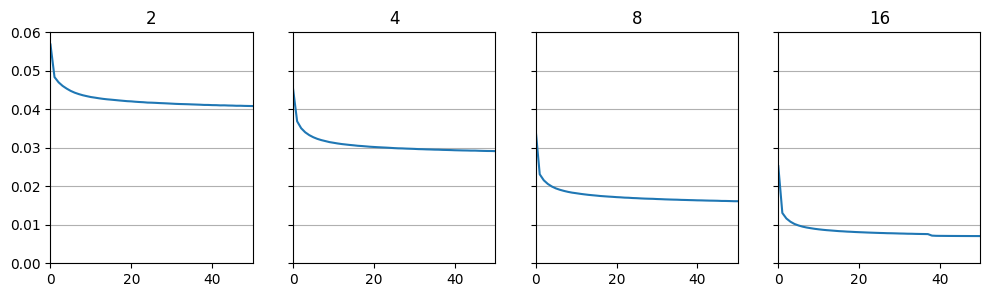

<Figure size 640x480 with 0 Axes>

In [9]:
loss_plot([2,4,8,16])

### Evaluating the best model, with latent space dimension of 16

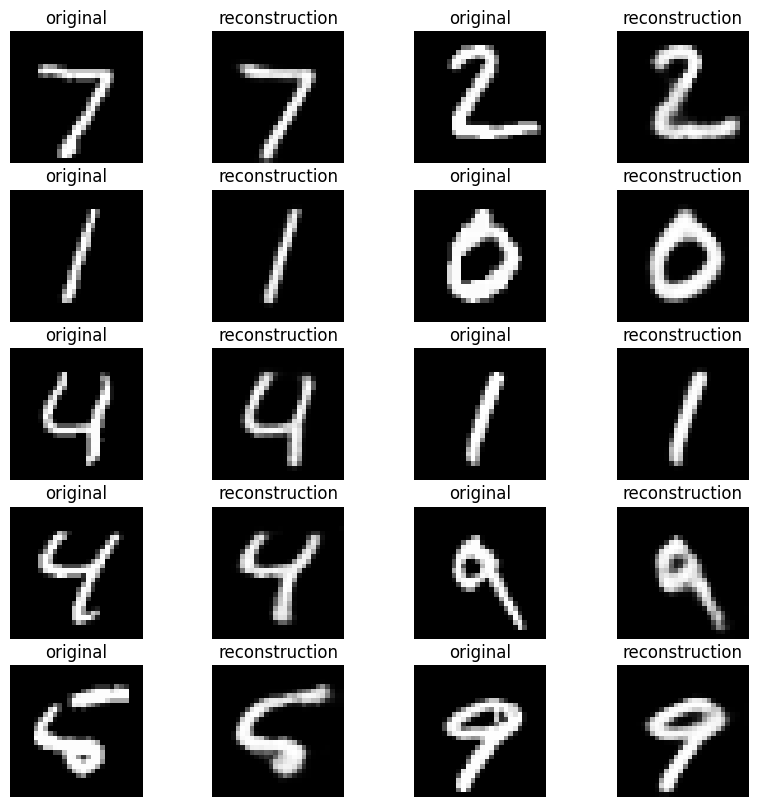

In [10]:
LATENT_SPACE_DIM = 16
AE = load_model(LATENT_SPACE_DIM)

i, _ = next(iter(test_loader))
recon = AE(i.to(device))
    
show_preds(i, recon, 10)

### Results with different latent space dimensions

![varying latent space dimension](notebook_images/varying_latent_space.png)

As we increase the dimensionality of the latent space, the information bottleneck becomes less restrictive, allowing the encoder to preserve more structural details. Consequently, the reconstruction quality improves significantly.

However, notice that a certain degree of fuzziness or blurriness persists even with larger latent spaces. This is a fundamental artifact of using Mean Squared Error (MSE) as the reconstruction loss. When the autoencoder is uncertain about the exact placement of a sharp edge or fine detail, MSE penalizes the model less if it outputs a "safe" mathematical average of the possible pixel values. Visually, this pixel-wise averaging manifests as blur—a limitation that other architectures, such as Generative Adversarial Networks (GANs), explicitly aim to overcome by replacing MSE with adversarial loss.
### The Information Bottleneck and The Identity Function

When observing that larger latent spaces yield better reconstructions, it is tempting to increase the latent dimension indefinitely. However, the bottleneck is the most critical design feature of the autoencoder.

Because our MNIST images have $28 \times 28 = 784$ pixels, our latent space must be strictly smaller than 784. This forces the model to be an undercomplete autoencoder. By restricting the capacity of the network, we force it to discover correlations, patterns, and compress the data into a meaningful representation.

If we were to use an overcomplete autoencoder (where the latent dimension is equal to or greater than the input size), the network could simply learn the Identity Function—memorizing the input and perfectly copying pixels to the output without learning any useful hidden features. In such a scenario, the latent space becomes utterly useless for downstream tasks like anomaly detection or clustering.



### Graphical Interpretation

A latent space with only two dimensions is clearly insufficient to accurately reconstruct the input images. However, restricting the bottleneck to 2D allows us to easily visualize the latent manifold. These plots are invaluable for illustrating the inner workings of the AE, showing how it clusters different classes and how the decoder behaves when moving through the continuous space.

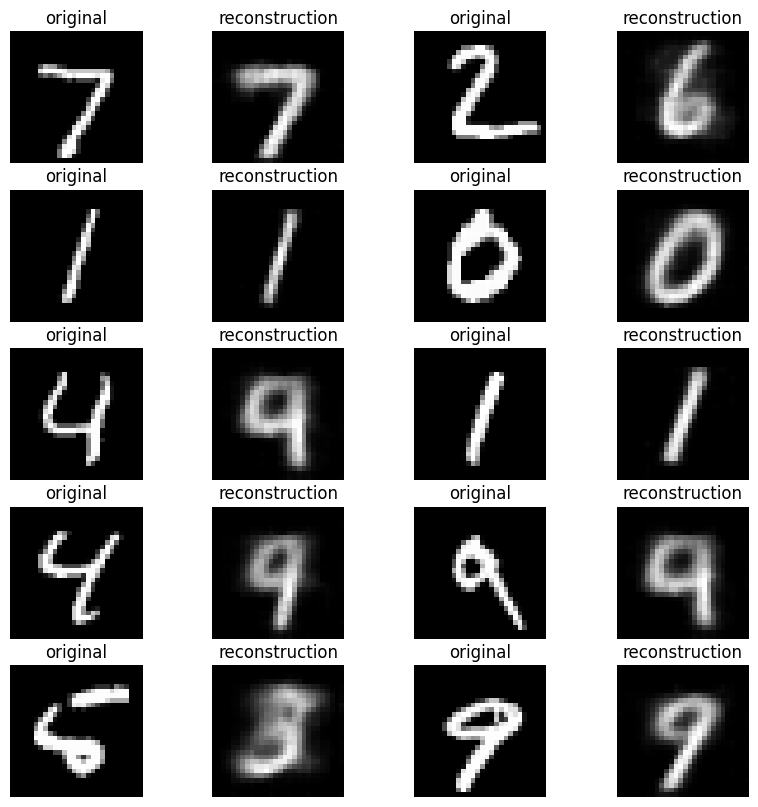

In [11]:
LATENT_SPACE_DIM = 2
AE = load_model(LATENT_SPACE_DIM)

i, _ = next(iter(test_loader))
recon = AE(i.to(device))
    
show_preds(i, recon, 10)

### Plotting the latent space with class color coding

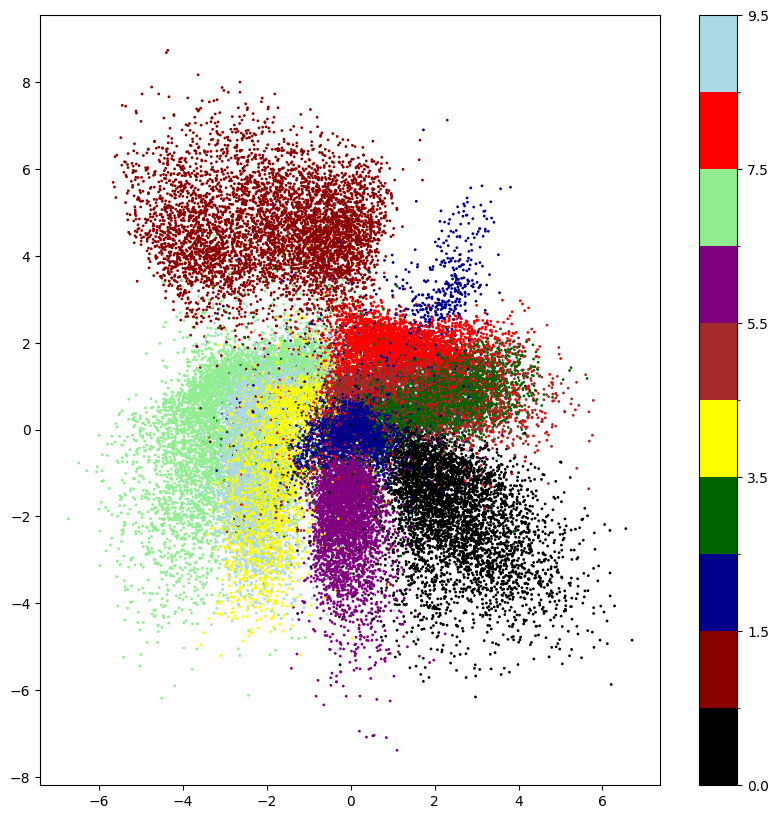

In [12]:
# this only works if the latent space dimension is 2


if LATENT_SPACE_DIM == 2:

    encoded = []
    targets = []
    for i,t in train_loader:
        encoded.extend(AE.encoder(i.to(device)).cpu().detach().numpy())
        targets.extend(t)

    x = np.array(encoded)[:,0]
    y = np.array(encoded)[:,1]

    plot_scatter(x,y,targets)#, [2,-1, 2.5, -0.5])


## Analyzing the Latent Distribution

Looking at the 2D scatter plot of our test set mapped into the latent space, several core properties of the standard AE become clear:

- Unconstrained Manifold: The AE does not enforce any specific shape or density on its latent space. It simply spreads the data out to minimize reconstruction error. 

- Natural Pixel-wise Clustering: Even though the model was trained entirely unsupervised (without labels), the digits naturally group together by color. This proves the encoder successfully extracted meaningful structural features. Digits with highly unique shapes are pushed to the edges, while digits with overlapping pixel structures are forced closer together.

- Entanglement: In the dense center of the plot, several classes overlap heavily. Because we squeezed the entire dataset into just 2 dimensions, the network lacks the capacity to perfectly separate structurally ambiguous digits, forcing them to share the same latent coordinates.

Show a reconstruction from the latent space 

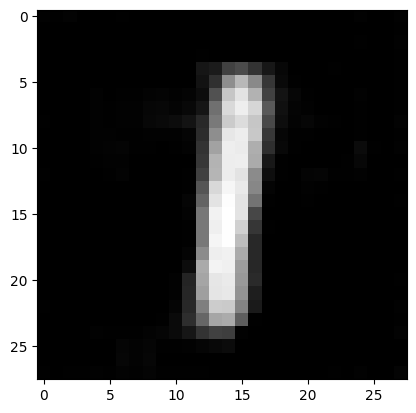

In [13]:
# change the point coordinates to obtain the different digits
LATENT_SPACE_DIM = 2

point = [-2.5,4]

if LATENT_SPACE_DIM == 2:
    pred = AE.decoder(torch.Tensor([point]).to(device))
    plt.imshow(np.transpose(pred[0].cpu().detach().numpy(), (1,2,0)), 
               cmap=plt.cm.gray)

### Exploring the latent space

Exploring latent space in the interval [-5,5] for each of its dimensions

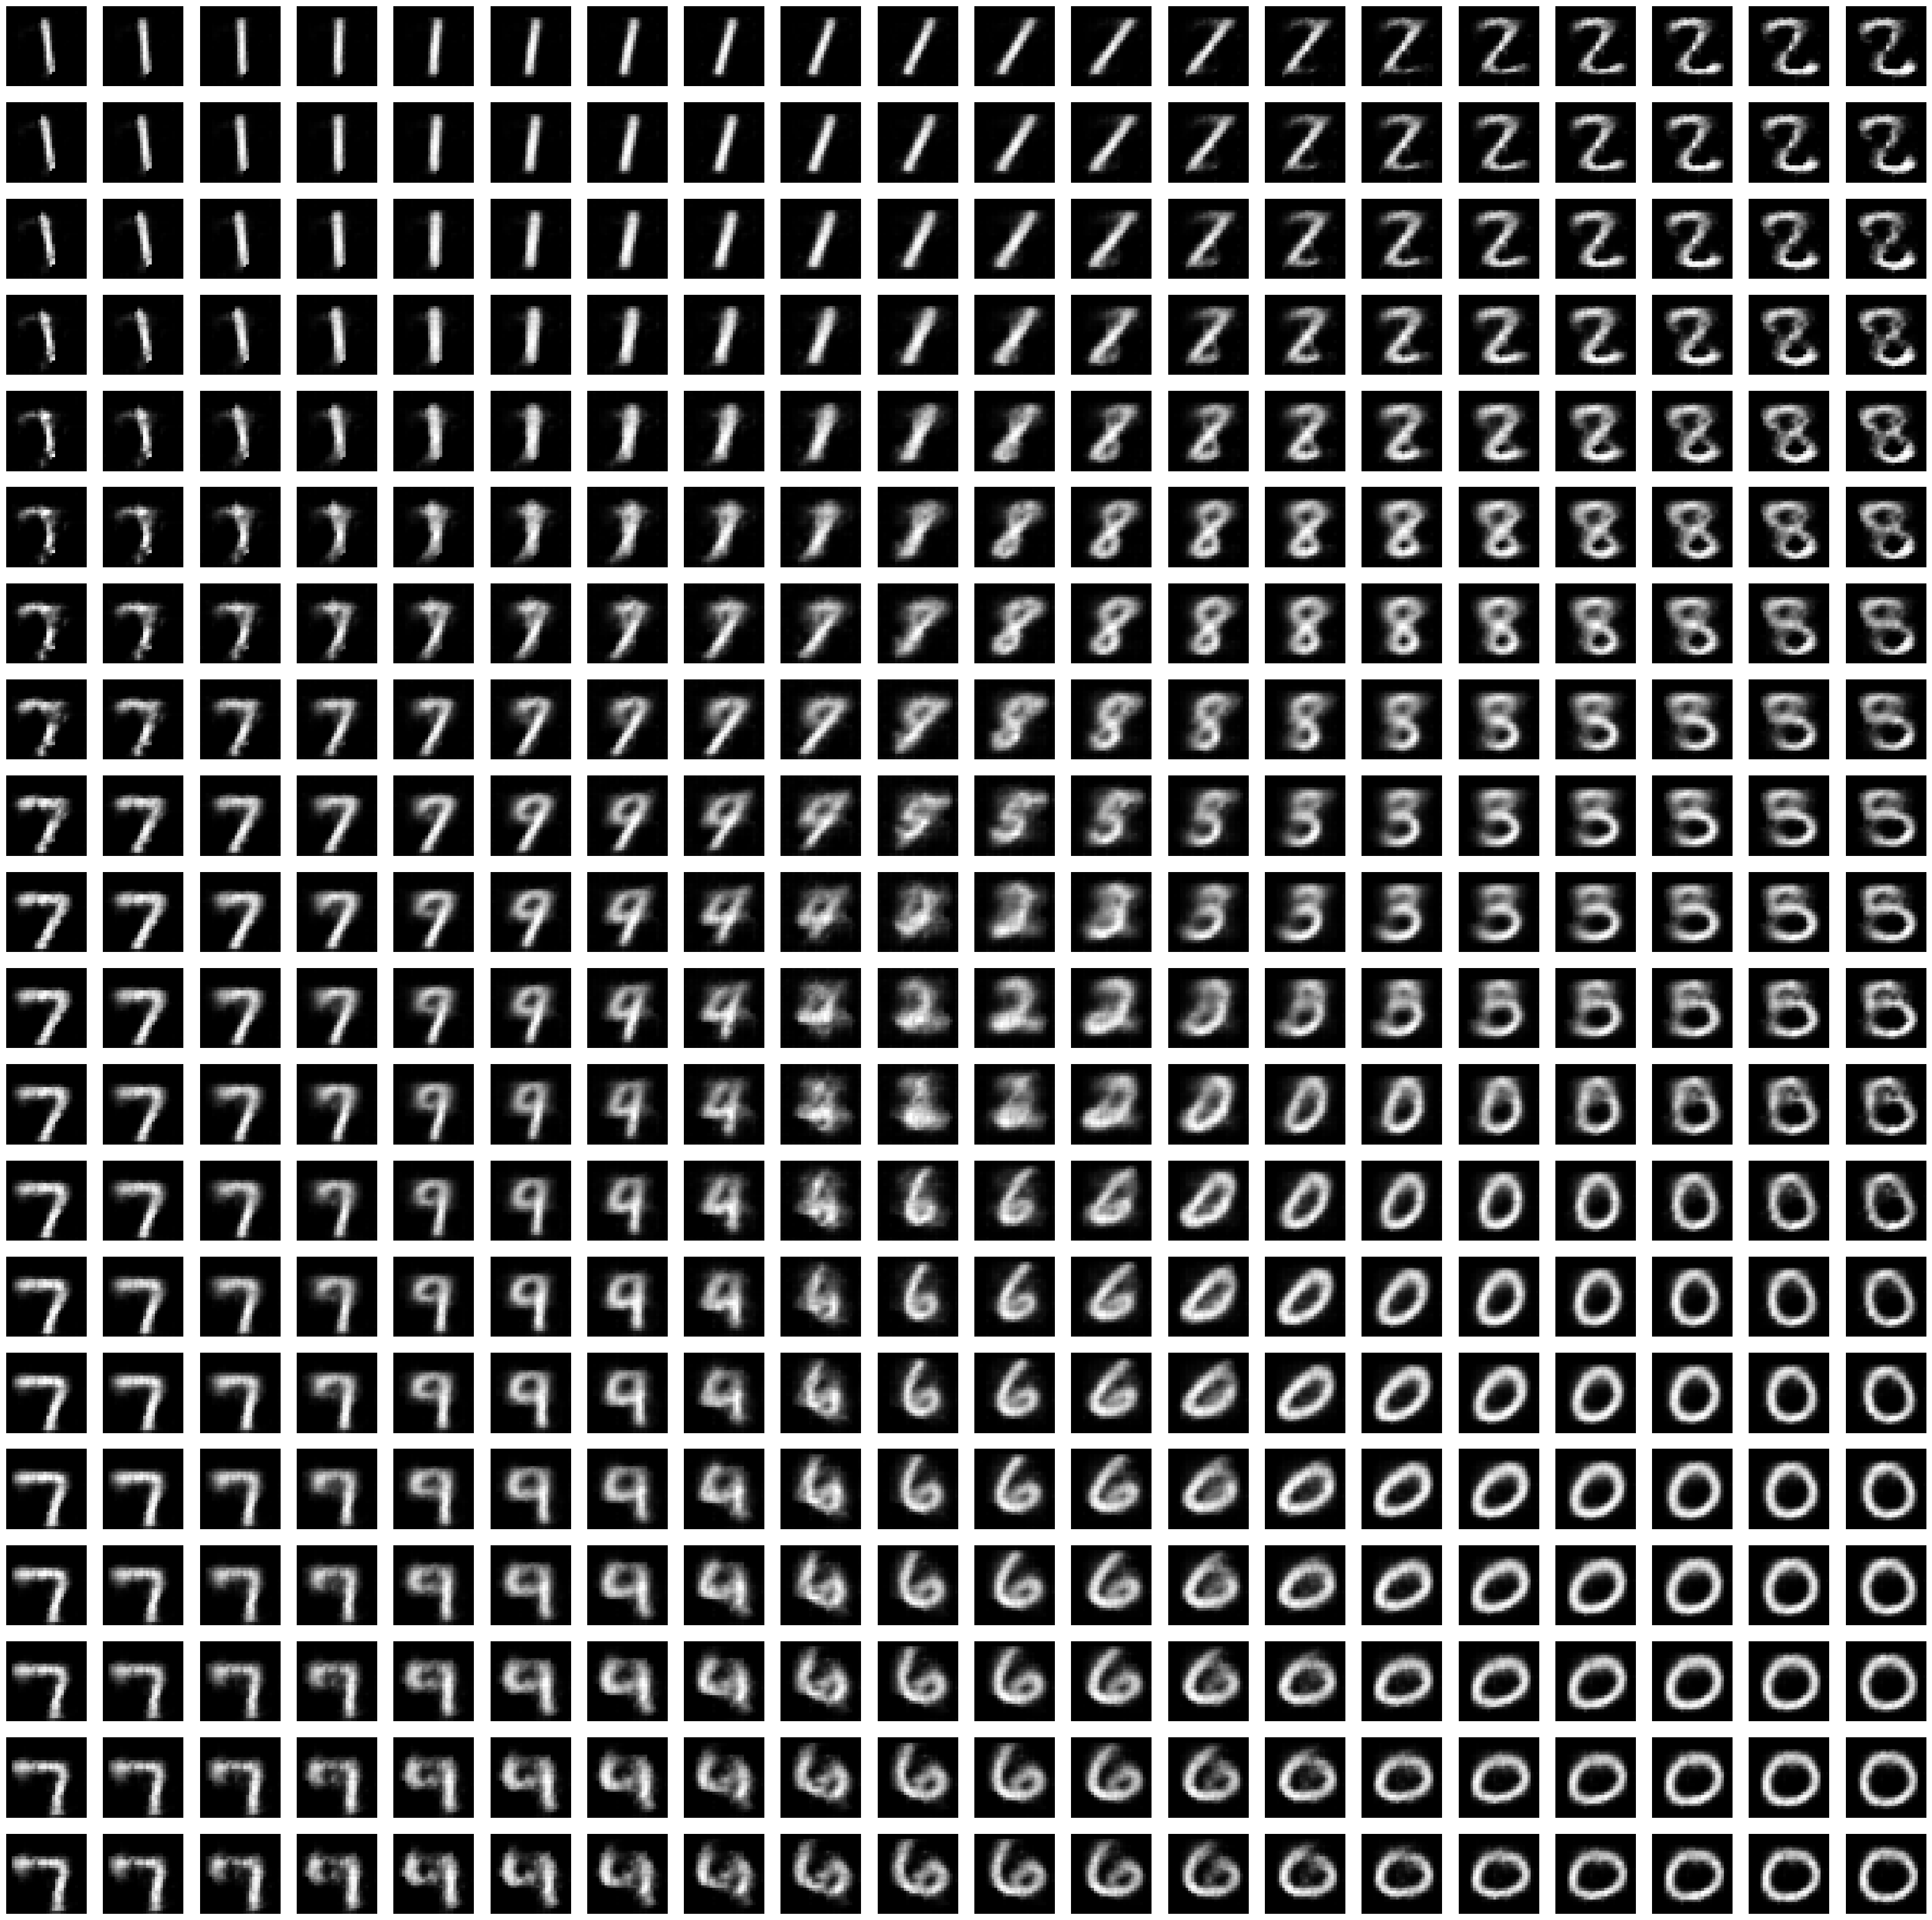

<Figure size 640x480 with 0 Axes>

In [14]:
if LATENT_SPACE_DIM == 2:
    limit = 5
    steps = 20

    step = (2.0 * limit) / steps

    vector_generation = [[-limit + j*step, limit - i*step] 
                                for i in range(steps) for j in range(steps)]

    predictions = AE.decoder(torch.Tensor(vector_generation).to(device))

    vcpi_util.show_predicted_images(steps, steps, 
                                    predictions.cpu().detach(), 10)


# Anomaly Detection

AEs are widely used for unsupervised anomaly detection. The underlying assumption is that an AE trained exclusively on a specific distribution of data (in our case, handwritten digits) will learn to compress and reconstruct only the features relevant to that distribution.

If we feed the trained model an out-of-distribution (OOD) sample—an anomaly—the encoder will map it to an unfamiliar region of the latent space, and the decoder will fail to reconstruct it accurately. By calculating the Reconstruction Error (MSE), we can mathematically quantify how "anomalous" an image is.

To demonstrate this robustly, we will:

- Calculate the reconstruction error for our normal data (MNIST test set) to establish a baseline.

- Define a statistical anomaly threshold.

- Feed the model out-of-distribution images (from the FashionMNIST dataset) and observe the resulting reconstruction error.

## Establish the Normal Baseline

In [15]:
LATENT_SPACE_DIM = 16
AE = load_model(LATENT_SPACE_DIM)

# Calculate MSE for the entire MNIST test set
id_errors = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        reconstructions = AE(images)
        
        # Calculate MSE per image in the batch
        mse_per_image = torch.mean((images - reconstructions)**2, dim=[1,2,3])
        id_errors.extend(mse_per_image.cpu().numpy())

id_errors = np.array(id_errors)

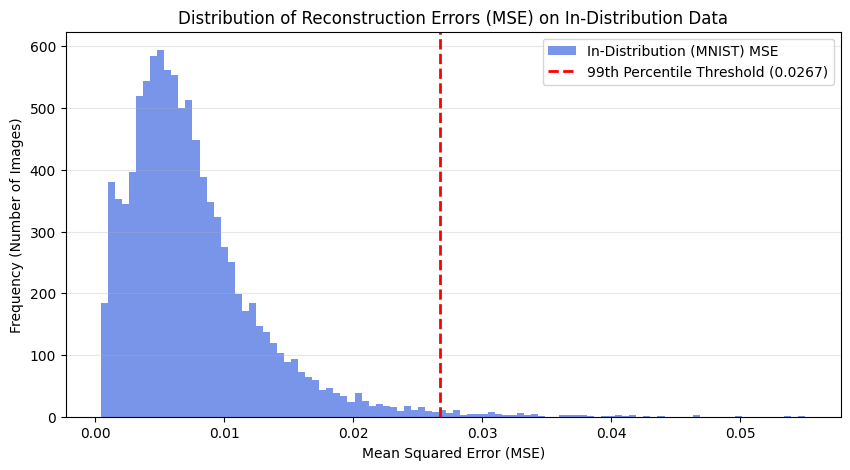

In-Distribution MSE - Mean: 0.0076, Std: 0.0053
Anomaly Threshold (99th percentile): 0.0267


In [16]:
# Define threshold as the 99th percentile of normal errors
threshold = np.percentile(id_errors, 99)

show_error_distribution(id_errors, threshold)

### A Note on Setting the Threshold

In this demonstration, we arbitrarily set the threshold at the 99th percentile of the In-Distribution (MNIST) reconstruction errors. While this is a common starting point, in a real-world production environment, the threshold is a critical hyperparameter that dictates the tradeoff between precision and recall:

Lowering the threshold (e.g., 95th percentile): Increases the sensitivity of the detector. The model will successfully catch almost all anomalies (fewer False Negatives), but it will also incorrectly flag many messy or poorly written normal digits as anomalies (more False Positives).

Raising the threshold (e.g., 99.9th percentile): Makes the detector more conservative. It will rarely trigger a false alarm on normal data, but it risks missing subtle anomalies that structurally resemble normal data.

Ultimately, the optimal threshold is usually determined using a labeled validation set (if available) by plotting a Precision-Recall curve or an ROC curve, and selecting the point that maximizes the F1-score or meets specific dataset requirements.

## Prepare the Anomaly Dataset (FashionMNIST)

We will use the FashionMNIST dataset, which contains $28 \times 28$ grayscale images of clothing. Because our network only knows how to draw curves and loops that make up numbers, it should completely fail to reconstruct a shoe or a shirt.

In [17]:
anomaly_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, 
    download=True, transform=transforms.ToTensor()
)

anomaly_loader = torch.utils.data.DataLoader(anomaly_dataset, batch_size=10, shuffle=True)

## Comparing the Reconstruction Error for the two Distributions

The graph show two different distributions with a small overlap. This overlap implies that some images from Fashion MNIST (our out-of-distribution test set) will not be identified as anomalies.

This happens when a FashionMNIST image coincidentally shares a high degree of pixel overlap with a standard digit—for example, a thin, vertical dress or trouser that structurally resembles a '1', or an image with very few active foreground pixels. Because the autoencoder is optimized purely for pixel-wise Mean Squared Error, it can accidentally reconstruct these simple, low-complexity anomalies well enough to produce an error that falls below our established threshold.

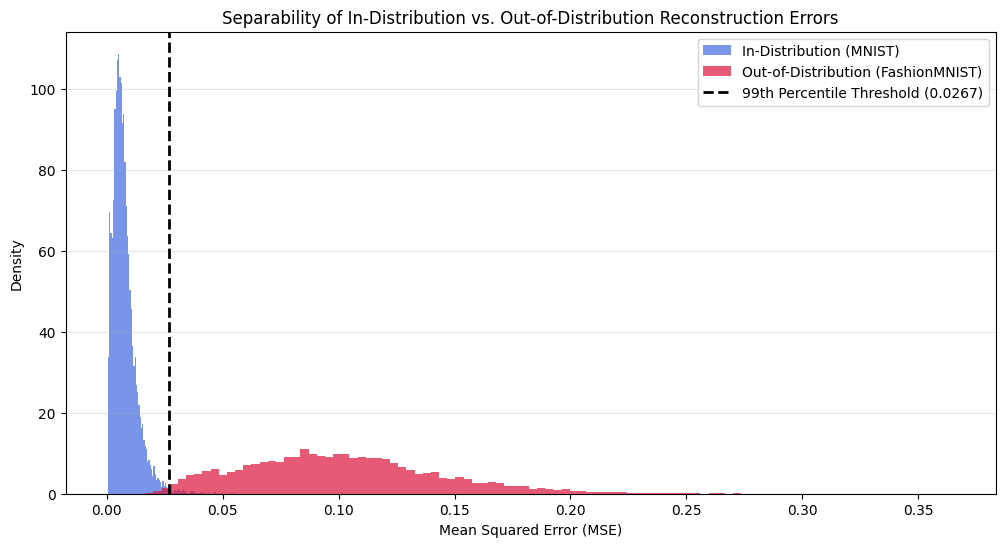

In-Distribution (MNIST) MSE        - Mean: 0.0076, Std: 0.0053
Out-of-Distribution (Fashion) MSE  - Mean: 0.1012, Std: 0.0420


In [18]:
# 1. Gather OOD errors (FashionMNIST)
ood_errors = []
with torch.no_grad():
    # Iterating over the full anomaly_loader we defined earlier
    for images, _ in anomaly_loader:
        images = images.to(device)
        reconstructions = AE(images)
        
        # Calculate MSE per image
        mse_per_image = torch.mean((images - reconstructions)**2, dim=[1,2,3])
        ood_errors.extend(mse_per_image.cpu().numpy())

ood_errors = np.array(ood_errors)

show_both_error_distribution(id_errors, ood_errors, threshold)

## Evaluate Anomalies

Now, we pass the clothing images through the digit-trained AE. We expect the MSE to vastly exceed our established threshold.

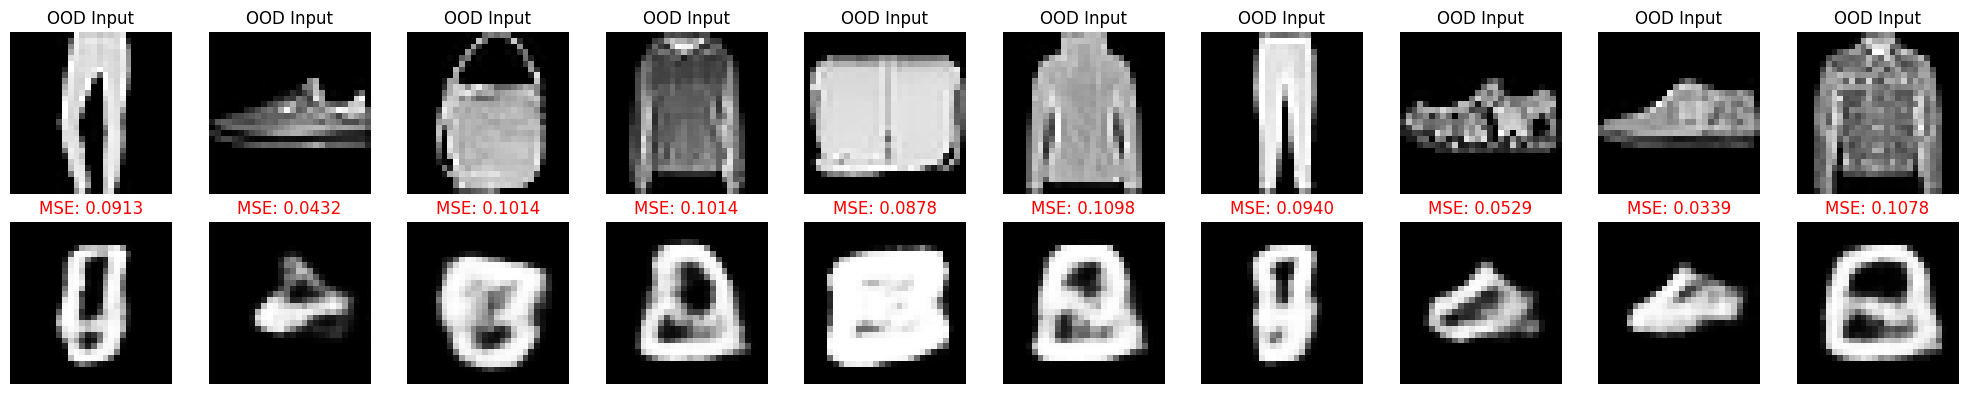

In [19]:
# Fetch a batch of letters
anomaly_images, _ = next(iter(anomaly_loader))
anomaly_images = anomaly_images.to(device)

with torch.no_grad():
    anomaly_recons = AE(anomaly_images)
    anomaly_errors = torch.mean((anomaly_images - anomaly_recons)**2, dim=[1,2,3]).cpu().numpy()

# Display the results
#Examining the False Positives (In-Distribution Anomalies)
show_anomaly_evaluation(anomaly_images, anomaly_recons, anomaly_errors, threshold)

## Examining the False Positives (In-Distribution Anomalies)

As mentioned before, some in-distribution images will be classified as anomalies. Below are some examples of some digits that are classified as out-of-distribution

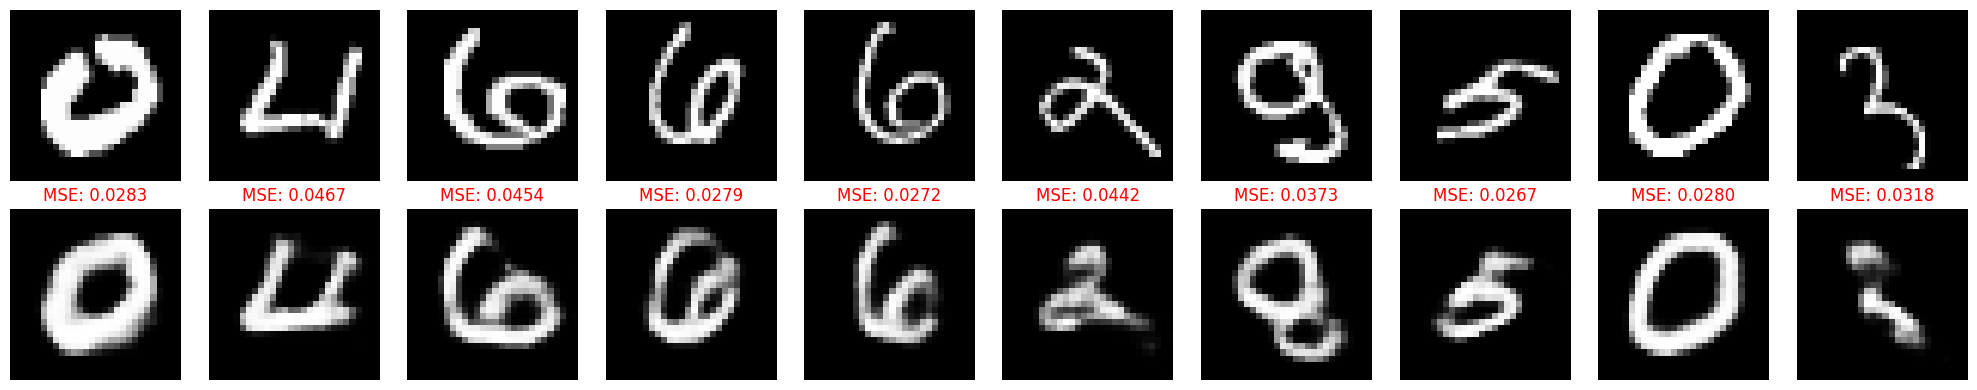

In [20]:
# Lists to store our 10 false positives
fp_images = []
fp_recons = []
fp_errors = []

AE.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        reconstructions = AE(images)
        
        # Calculate MSE for the batch
        errors = torch.mean((images - reconstructions)**2, dim=[1,2,3]).cpu().numpy()
        
        # Find indices in this batch that breach the threshold
        anomalous_idx = np.where(errors > threshold)[0]
        
        for idx in anomalous_idx:
            fp_images.append(images[idx].cpu().numpy().squeeze())
            fp_recons.append(reconstructions[idx].cpu().numpy().squeeze())
            fp_errors.append(errors[idx])
            
            # Early stop as soon as we hit 10 images
            if len(fp_images) == 10:
                break
                
        if len(fp_images) == 10:
            break

# Display the False Positives
show_false_positives(fp_images, fp_recons, fp_errors, threshold)

# Content-Based Image Retrieval 

Content-Based Image Retrieval (CBIR) is the process of finding images in a large database that are visually or semantically similar to a given query image.

While we could theoretically compare images by calculating the pixel-wise difference between them, this approach is highly brittle; slight shifts, rotations, or changes in line thickness will result in massive pixel errors, even if the images represent the exact same digit.

Instead, we perform the search in the latent space:

1. Feature Extraction: We pass every image in our dataset through the trained encoder to obtain its compressed, lower-dimensional latent representation. This latent vector serves as a "feature signature" that quantifies the structural contents of the image.

2. Querying: When a new query image is provided, we encode it into the exact same latent space.

3. Distance Calculation: We compute the mathematical distance (e.g., Euclidean distance or Mean Squared Error) between the query's latent vector and all the stored dataset vectors.

4. Retrieval: By sorting these distances from smallest to largest, we can retrieve the top $n$ nearest neighbors. Because the autoencoder groups structurally similar images close together in the latent manifold, the retrieved images will visually match the query.

## Feature extraction for training set

In [21]:
# feature extraction for training set
features = []

for i in range(train_set.__len__()):
    features.extend(AE.encoder(train_set[i][0].view(1,1,28,28).to(device)))

# build a dict from index to features from latent_space
indexes = list(range(0, train_set.__len__()))
data = {"indexes": indexes, "features": features}

Load an image

[ -1.2921059  -7.5604453 -19.196747   11.687626    9.305186  -18.388865
  -3.867614    1.6473608  -0.3880561 -10.141907    0.9149567  -1.0360559
   4.3160686 -11.878236    5.1962957  -6.165412 ]


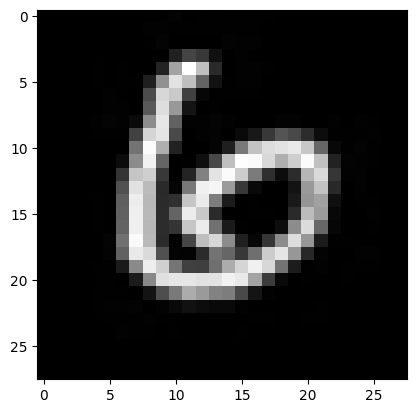

In [22]:
image_path = 'contentRetrievalImages/6.jpg'

img = Image.open(image_path).convert('L').resize((28,28))
img_tensor = transform(img).to(device).view(1,1,28,28)

#predict
dataLatent = AE.encoder(img_tensor).cpu().detach().numpy().squeeze()

print(dataLatent)
plt.imshow(img, cmap='gray')

# Querying and retrieval

Get 50 closest images in latent space

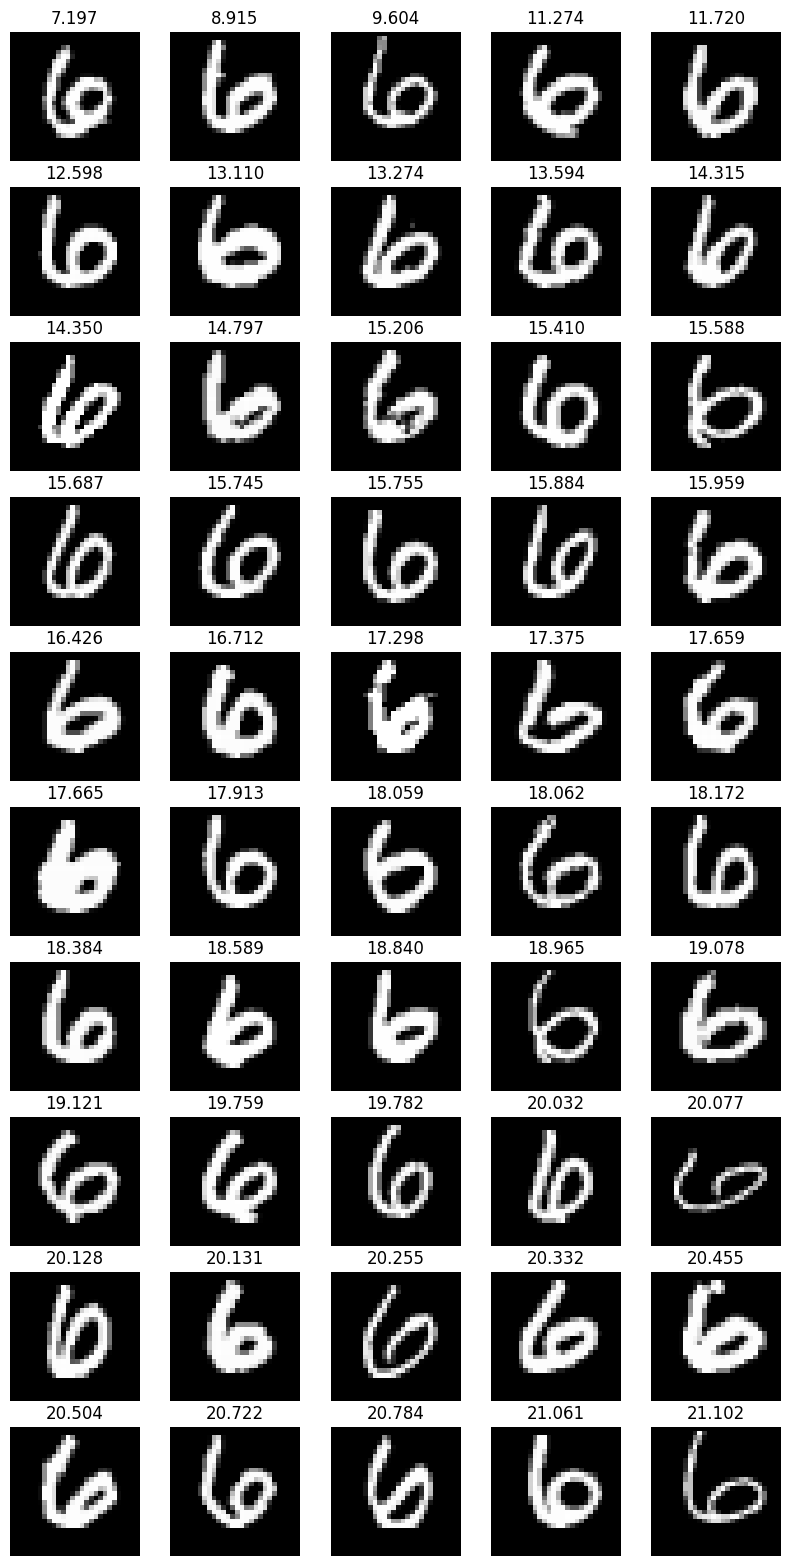

In [23]:
# compute mse error in latent space between image and elements 
# from training set
results = []
for i in range(len(data['indexes'])) :    
    err = np.sum((dataLatent - data['features'][i].cpu().detach().numpy())**2)
    err /= float(dataLatent.shape[0])
    results.append([err, i])

# sort images by error    
top50 = sorted(results)[:50]

show_content_retrieval(train_set, top50) 

### A Note on Distance Metrics in Latent Space
 
When computing the "distance" between the query's latent vector and the dataset vectors, the choice of mathematical metric matters:

Euclidean Distance (L2): Measures the straight-line distance between two points in the latent space. Because our AE was trained using Mean Squared Error (which is directly related to Euclidean distance), this is the most mathematically consistent metric to use for our specific model.

Cosine Similarity: Measures the angle between two vectors rather than their magnitude. In highly complex, high-dimensional latent spaces, Cosine Similarity may yield better semantic retrieval because it ignores absolute scale. 

# Denoising Autoencoder (DAE)

![denoiser](notebook_images/autoencoder_denoiser.jpg)


Up to this point, our autoencoder has been trained to simply reconstruct the exact image it was fed. While this works for compression, the model risks learning a brittle, superficial mapping.

To force the model to learn truly robust, high-level structural features, we can modify the training objective: we deliberately corrupt the input data with noise, but calculate the reconstruction loss against the original, clean image.

This architecture is known as a Denoising Autoencoder (DAE). Introduced by Pascal Vincent et al. (2008), this approach ensures that the encoder cannot simply memorize pixel locations. Instead, it must learn the underlying invariant structure of the data (e.g., recognizing that a digit is a continuous loop and filling in the missing pixels) to successfully separate the signal from the noise.

In this example, we will apply random "salt" noise (randomly turning pixels stark white) to our MNIST dataset on-the-fly during training. The noisy images will serve as the input to the encoder, and the targets for the Mean Squared Error loss will be the original, clean images.

**Ref:**

Vincent, P., Larochelle, H., Lajoie, I., Bengio, Y., & Manzagol, P.-A. (2010). [Stacked Denoising Autoencoders: Learning Useful Representations in a Deep Network with a Local Denoising Criterion](https://www.cs.toronto.edu/~larocheh/publications/icml-2008-denoising-autoencoders.pdf). Journal of Machine Learning Research, 11, 3371–3408

## Create noisy train and test data

To create the noisy dataset we create a custom class derived from Dataset.



In [24]:
class CustomDataLoader(torch.utils.data.Dataset):

    def __init__(self, path, transform=None):
        super().__init__()
        
        self.path = path
        self.transform = transform
        
        # Sort classes to ensure consistent index mapping across different operating systems
        self.classes = sorted([x.name for x in os.scandir(path) if x.is_dir()])
        self.classes_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        # Store ONLY the file paths, not the loaded images
        self.paths = list(pathlib.Path(path).glob('*/*.jpg'))

    def __len__(self):
        return len(self.paths)    

    def __getitem__(self, idx):
        # 1. Get the path and label for the current index
        p = self.paths[idx]
        class_name = p.parent.name
        label = self.classes_to_idx[class_name]

        # 2. Open the image dynamically
        # Using a context manager ('with open') prevents "Too many open files" errors 
        # when using num_workers > 0 in the DataLoader
        with open(p, 'rb') as f:
            clean_img = Image.open(f).convert("L")
            
            # 3. Apply noise on-the-fly (Dynamic Data Augmentation)
            img_np = np.array(clean_img)
            salt_img_np = skimage.util.random_noise(img_np, mode='salt', amount=0.05)
            
            # Convert back to uint8 and PIL Image for compatibility with torchvision transforms
            salt_img_uint8 = np.array(255 * salt_img_np, dtype=np.uint8)
            noisy_img = Image.fromarray(salt_img_uint8)

        # 4. Apply transforms
        if self.transform:
            noisy_tensor = self.transform(noisy_img)
            clean_tensor = self.transform(clean_img)
        else:
            noisy_tensor = noisy_img
            clean_tensor = clean_img

        return noisy_tensor, clean_tensor, label

The MNIST dataset with JPG images can be obtained in https://www.kaggle.com/datasets/scolianni/mnistasjpg?resource=download

In [25]:
dataset_set_noisy = CustomDataLoader('data/MNIST/train', transform)

train_size = int(0.8 * len(dataset_set_noisy))
val_size = len(dataset_set_noisy) - train_size

train_set_noisy, val_set_noisy = \
    torch.utils.data.random_split(dataset_set_noisy, [train_size, val_size])


In [26]:

train_loader_noisy = torch.utils.data.DataLoader(train_set_noisy, 
                                    batch_size = BATCH_SIZE, shuffle=True)
val_loader_noisy = torch.utils.data.DataLoader(val_set_noisy, 
                                    batch_size = BATCH_SIZE)

### Show images from the noisy training set



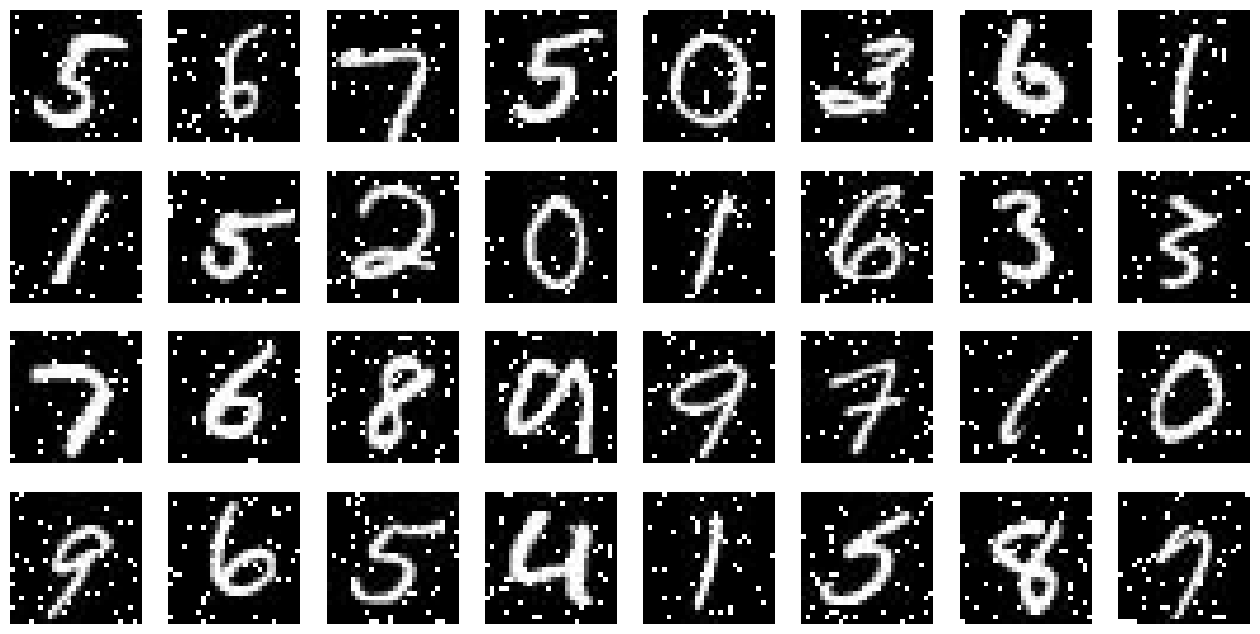

<Figure size 640x480 with 0 Axes>

In [27]:
noisy, clean, classes = next(iter(train_loader_noisy))

show_images(4,8, noisy, classes) 

### Train the autoencoder with the noisy data

In [28]:
LATENT_SPACE_DIM = 16

AE_denoise = AutoEncoder(LATENT_SPACE_DIM)
AE_denoise.to(device)  

if TRAIN:
    opt = torch.optim.Adam(AE_denoise.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', 
                                                factor = 0.1, patience=3)
    early_stop = Early_Stopping(9)
    loss_fn = torch.nn.loss_fn = torch.nn.MSELoss()

    history=train(AE_denoise, train_loader_noisy, val_loader_noisy, 
                100, loss_fn, opt,  scheduler, early_stop, 
                f'{MODEL_PATH}/autoencoder_denoiser_{LATENT_SPACE_DIM}' )

Load the denoiser model

In [29]:
AE_denoise = load_model(LATENT_SPACE_DIM,f'{MODEL_PATH}/autoencoder_denoiser_{LATENT_SPACE_DIM}_best.pt')

### Visual Inspection regarding noise removal

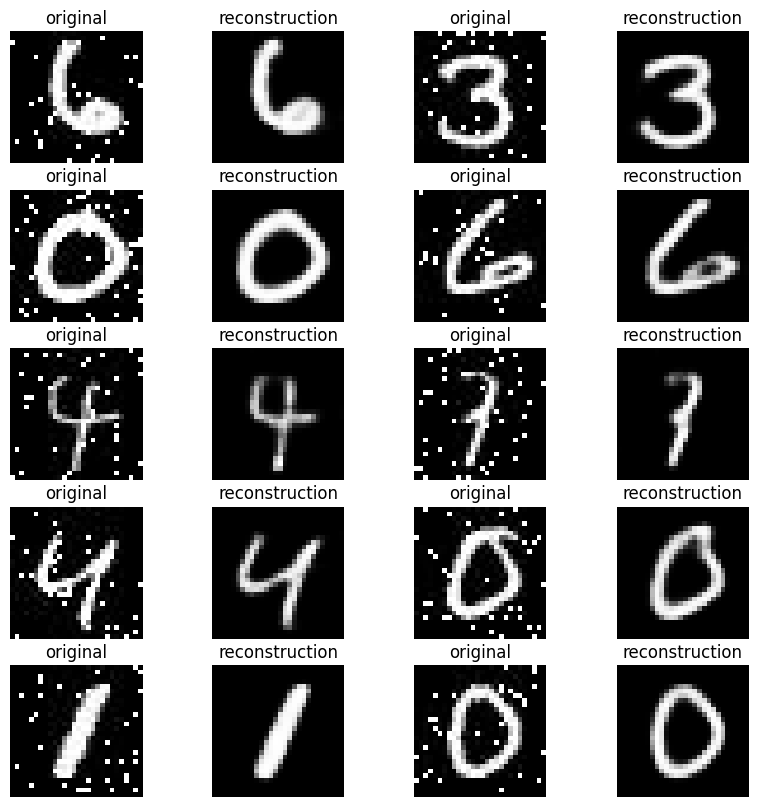

In [30]:
test_set_noisy = CustomDataLoader('data/MNIST/test', transform)
test_loader_noisy = torch.utils.data.DataLoader(test_set_noisy, 
                                        batch_size=BATCH_SIZE, shuffle=True)

noisy, _, _ = next(iter(test_loader_noisy))
recon = AE_denoise(noisy.to(device))
    
show_preds(noisy, recon, 10)

The Denoiser was able to remove the noise efficiently, providing nearly perfect reproductions of the unsalted original. This confirms that the model successfully learned a robust mapping back to the true data manifold, ignoring the high-frequency salt-and-pepper corruption.

The next test shows results for both the AE and the Denoiser when faced with images with a much higher level of noise than was used in the training of the denoiser. While the standard AE struggles to output a meaningful digit, the denoiser is able to recover the digits in almost all cases.

In [31]:
# reload the AE model with the latent space dim = 18
LATENT_SPACE_DIM = 16
AE = load_model(LATENT_SPACE_DIM)

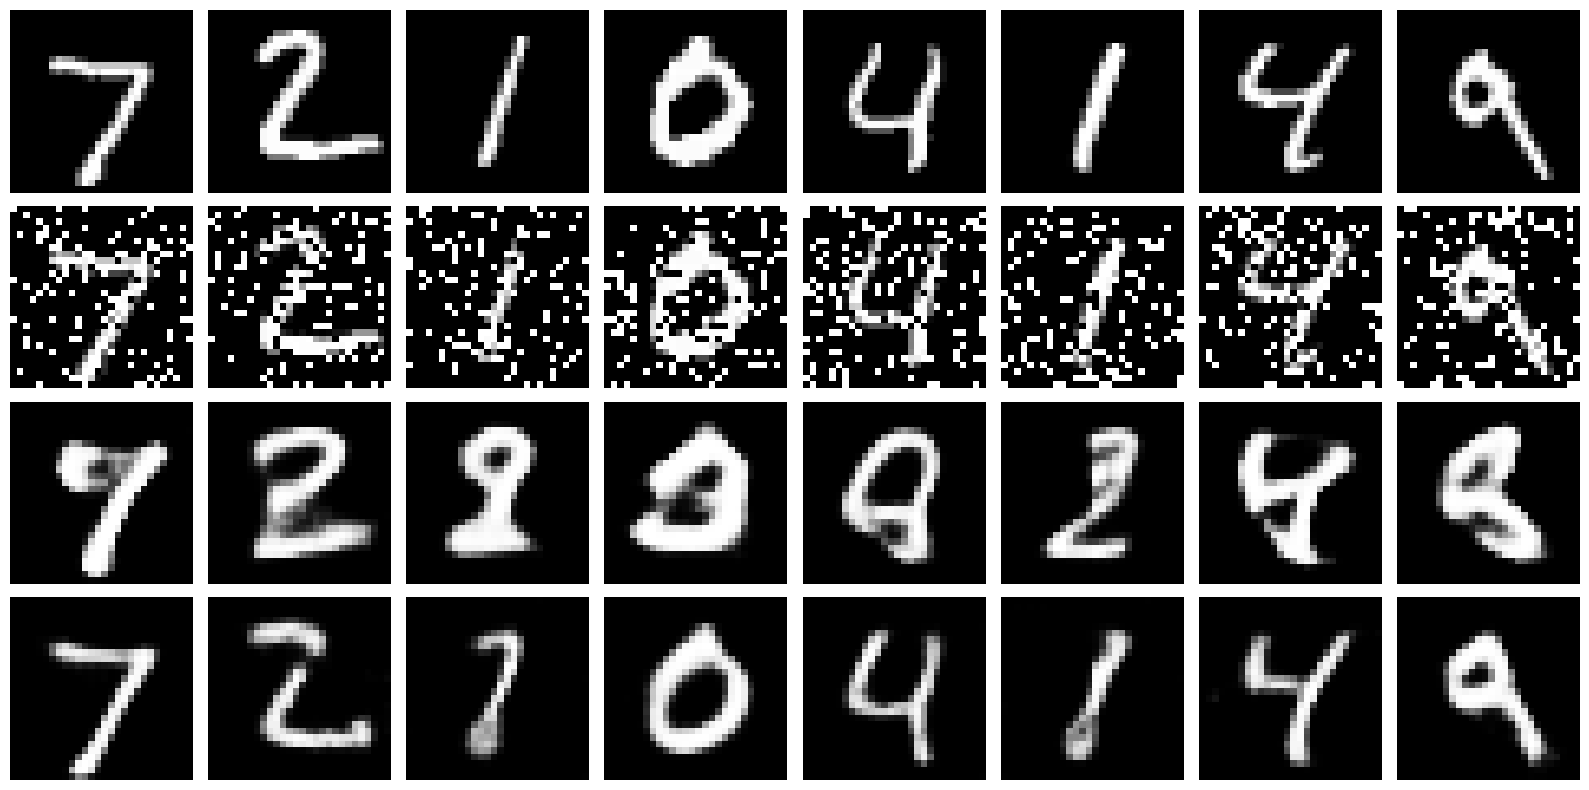

In [32]:
# Fetch a batch of clean images
clean_images, _ = next(iter(test_loader))
clean_images = clean_images.to(device)

# Apply extreme, unseen noise
heavy_noise_images = apply_extreme_noise(clean_images, amount=0.3)

# Reconstruct using both models
with torch.no_grad():
    recon_std_noisy = AE(heavy_noise_images)
    recon_dae_noisy = AE_denoise(heavy_noise_images)

compare_extreme_noise(clean_images, heavy_noise_images, recon_std_noisy, recon_dae_noisy)

The following experiment shows that both models achieve very similar Mean Squared Error (MSE) for reconstruction, and visual inspection does not reveal a substantial difference between the two.

In [33]:
# Ensure both models are in evaluation mode
AE.eval()
AE_denoise.eval()

standard_ae_loss = 0.0
dae_loss = 0.0
total_samples = 0

# Use the standard (clean) MNIST test_loader
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        
        # Reconstruct clean images using both models
        recon_standard = AE(images)
        recon_dae = AE_denoise(images)
        
        # Accumulate MSE for both
        standard_ae_loss += torch.nn.functional.mse_loss(recon_standard, images, reduction='sum').item()
        dae_loss += torch.nn.functional.mse_loss(recon_dae, images, reduction='sum').item()
        
        total_samples += images.size(0) * images.size(2) * images.size(3)

print(f"Standard AE MSE on Clean Data: {standard_ae_loss / total_samples:.6f}")
print(f"Denoising AE MSE on Clean Data:  {dae_loss / total_samples:.6f}")

Standard AE MSE on Clean Data: 0.007576
Denoising AE MSE on Clean Data:  0.007720


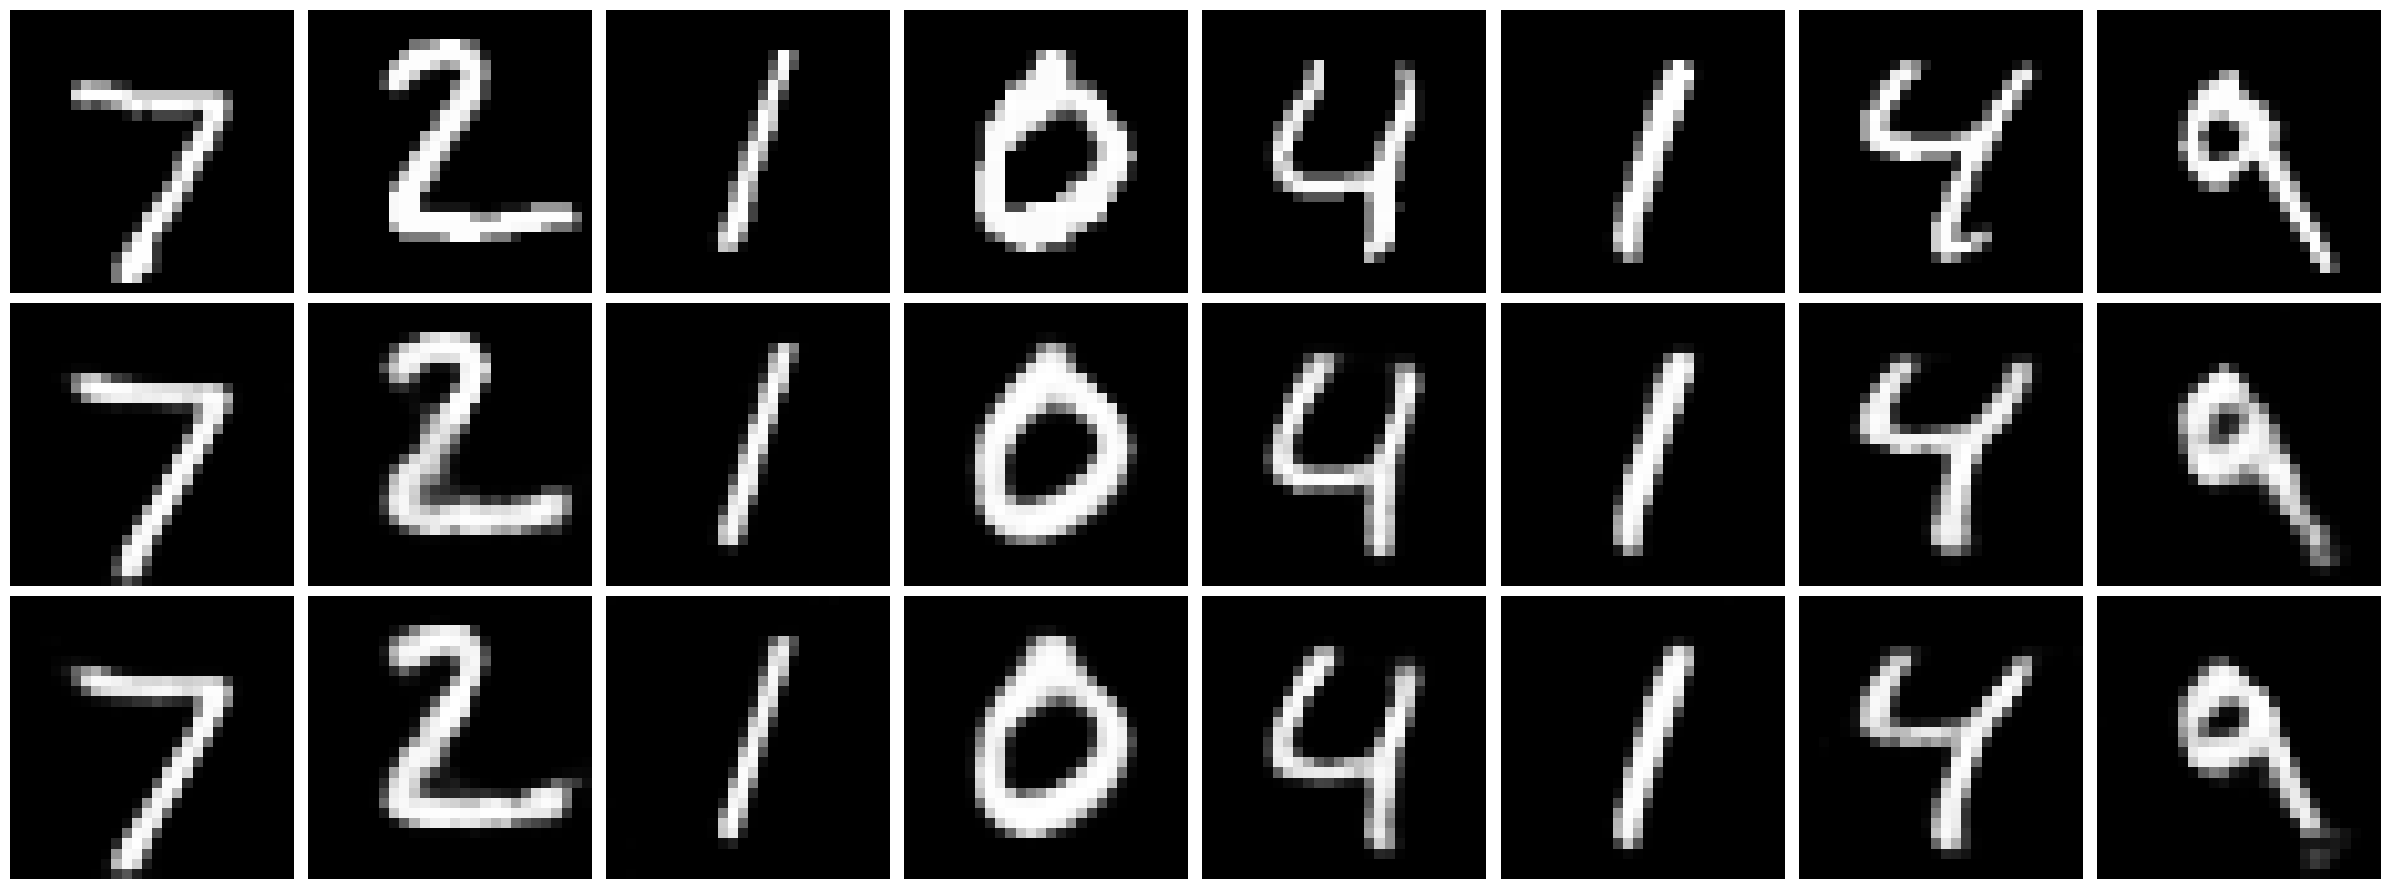

In [34]:
# Fetch one batch of clean test images
clean_images, _ = next(iter(test_loader))
clean_images = clean_images.to(device)

with torch.no_grad():
    recon_standard = AE(clean_images)
    recon_dae = AE_denoise(clean_images)

compare_reconstructions(clean_images, recon_standard, recon_dae)

The third experiment demonstrates the limits of the denoiser's generalization. When subjected to an unseen type of noise (Gaussian noise), the performance of both models degrades significantly. While some digits are still recognizable, the reconstructions are generally very poor.

Evaluating robustness against UNSEEN Gaussian Noise...
----------------------------------------
Standard AE MSE on Gaussian Noise: 0.048401
Denoising AE MSE on Gaussian Noise:  0.040478


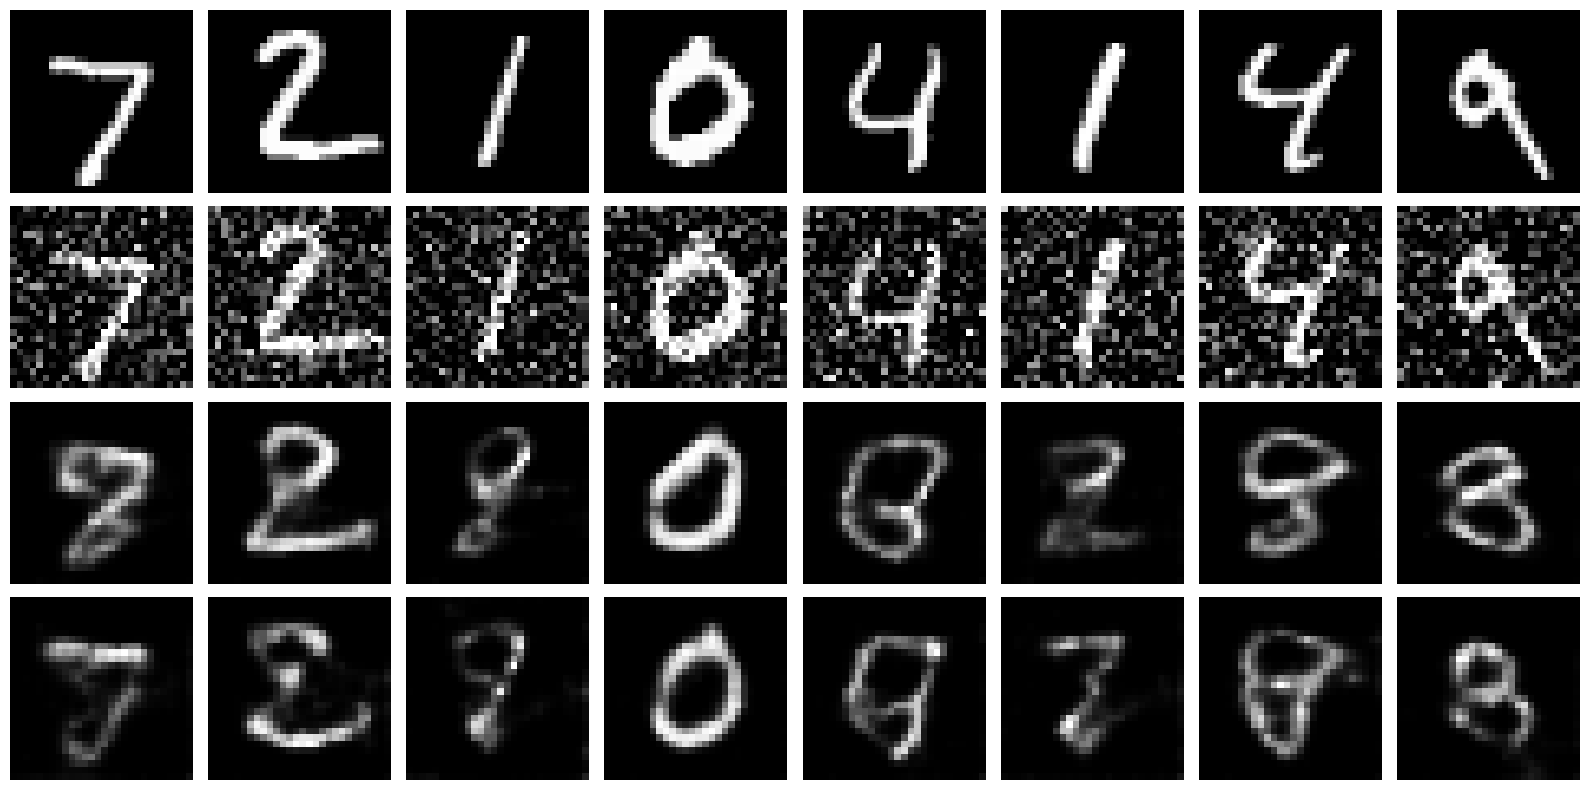

In [35]:
def apply_gaussian_noise(images, var=0.1):
    """Applies continuous Gaussian noise to the images."""
    noisy_images = images.clone().cpu().numpy()
    for i in range(noisy_images.shape[0]):
        noisy_images[i] = skimage.util.random_noise(noisy_images[i], mode='gaussian', var=var)
    return torch.tensor(noisy_images, dtype=torch.float32).to(device)

print("Evaluating robustness against UNSEEN Gaussian Noise...")

# Fetch a batch of clean images
clean_images, _ = next(iter(test_loader))
clean_images = clean_images.to(device)

# Apply Gaussian noise (never seen by either model)
gaussian_noisy_images = apply_gaussian_noise(clean_images, var=0.1)

AE.eval()
AE_denoise.eval()

# Reconstruct
with torch.no_grad():
    recon_std_gauss = AE(gaussian_noisy_images)
    recon_dae_gauss = AE_denoise(gaussian_noisy_images)

# 1. Quantitative MSE Comparison
mse_std_gauss = torch.nn.functional.mse_loss(recon_std_gauss, clean_images).item()
mse_dae_gauss = torch.nn.functional.mse_loss(recon_dae_gauss, clean_images).item()

print("-" * 40)
print(f"Standard AE MSE on Gaussian Noise: {mse_std_gauss:.6f}")
print(f"Denoising AE MSE on Gaussian Noise:  {mse_dae_gauss:.6f}")


show_gaussian_comparison(clean_images, gaussian_noisy_images, recon_std_gauss, recon_dae_gauss, 8)

The final test explores latent space interpolation. Here, the DAE provides slightly better results.

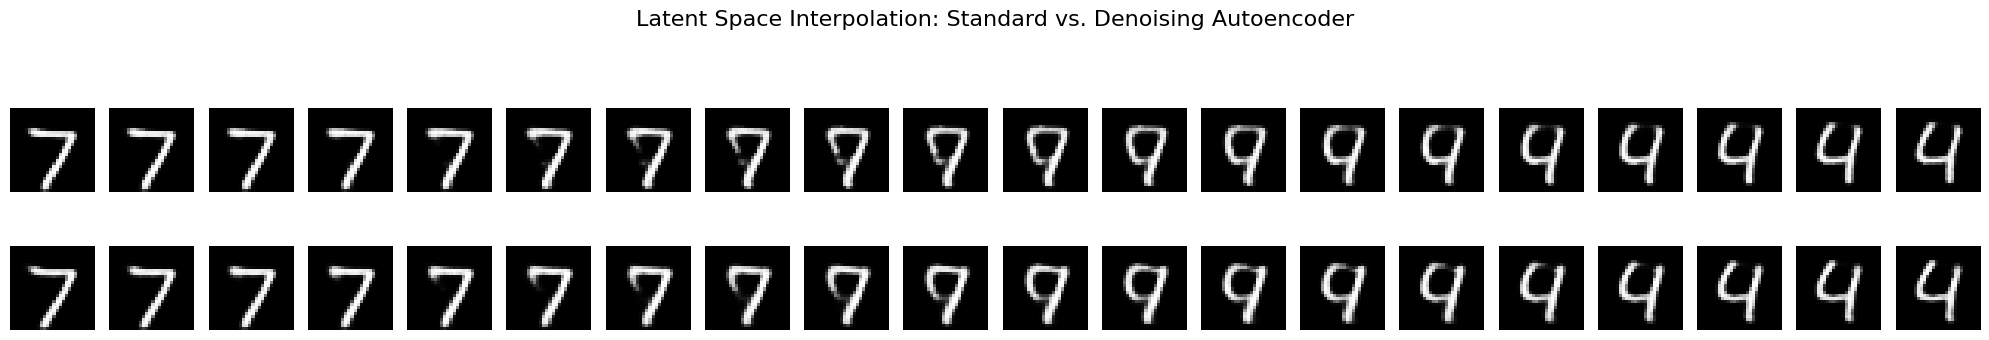

In [36]:
def interpolate_latent_space(model, img1, img2, steps=10):
    """Interpolates between two images in the latent space and decodes the steps."""
    model.eval()
    with torch.no_grad():
        # Encode both images
        z1 = model.encoder(img1.unsqueeze(0))
        z2 = model.encoder(img2.unsqueeze(0))
        
        # Create linear interpolation steps in latent space
        alphas = torch.linspace(0, 1, steps).to(device)
        interpolated_zs = torch.stack([(1 - a) * z1 + a * z2 for a in alphas]).squeeze(1)
        
        # Decode the interpolated vectors
        decoded_imgs = model.decoder(interpolated_zs)
        
    return decoded_imgs.cpu().numpy()


# Get two distinct images (e.g., a '1' and an '8')
# We will just grab the 1st and 13th images from the test batch
img_A = clean_images[0]
img_B = clean_images[4]

# Set the number of interpolation steps
steps = 20

# Generate interpolations
interp_std = interpolate_latent_space(AE, img_A, img_B, steps=steps)
interp_dae = interpolate_latent_space(AE_denoise, img_A, img_B, steps=steps)



plot_interpolation(interp_std, interp_dae)

### Denoiser Conclusion

In this section, we explored the differences between a Standard Autoencoder (AE) and a Denoising Autoencoder (DAE). Through a series of targeted experiments, we can draw several key conclusions about their behavior and latent space representations:

1. **Robustness and Manifold Learning**:
The DAE proved highly effective at recovering digits from severe salt-and-pepper noise, even successfully handling extreme noise levels that completely broke the standard AE. Importantly, this robustness came at no cost to baseline performance. 

2. **The Limits of Generalization**:
However, our Gaussian noise experiment revealed a crucial limitation. When faced with an out-of-distribution mathematical perturbation, both models struggled and produced poor reconstructions. This highlights that the DAE did not learn a universally robust "concept" of the digits; rather, it learned a defense mechanism specifically optimized against the salt-and-pepper distribution it saw during training.

3. **Latent Space Continuity**:
Finally, the latent space interpolation hinted at a structural difference between the two models. The standard AE, which only memorized an identity mapping, created a fragmented latent space resulting in heavy ghosting. The DAE provided slightly better transitions. 

